In [1]:
%load_ext autoreload
%autoreload 2

## Import data


In [2]:
import polars as pl

pdb_af3 = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet"
).filter(pl.col("pdb") != "8trr")
pdb_af3_conf = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_triad.conf_af3.parquet"
).filter(pl.col("pdb") != "8trr")

pdb_af3 = pdb_af3.join(
    pdb_af3_conf.select(pl.col("job_name"), pl.col("iptm"), pl.col("ptm")),
    on="job_name",
)

template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

## Plotting methods


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def plot_correlation(
    x: np.ndarray,
    y: np.ndarray,
    mhc_class: np.ndarray,
    xlabel: str,
    ylabel: str,
    method: str = "spearman",
    title: str | None = None,
    disp_mhc_class: bool = True,
) -> plt.Figure:
    """
    Scatter‐plot x vs y, color points by mhc_class ('I' or 'II'),
    compute and annotate either Pearson or Spearman correlation
    over all points.

    Parameters
    ----------
    x : np.ndarray
        1D array of values for the x‐axis.
    y : np.ndarray
        1D array of values for the y‐axis.
    mhc_class : np.ndarray
        1D array of same length, containing 'I' or 'II' for each point.
    xlabel : str
        Label for the x‐axis.
    ylabel : str
        Label for the y‐axis.
    method : {"pearson", "spearman"}
        Which correlation to compute.
    title : str, optional
        Plot title.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    """
    # validate inputs
    if not (len(x) == len(y) == len(mhc_class)):
        raise ValueError("x, y, and mhc_class must all be the same length")

    # compute overall correlation
    method = method.lower()
    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    elif method == "spearman":
        r, p = stats.spearmanr(x, y)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    fig, ax = plt.subplots()
    # plot by class
    for cls, color in [("I", "tab:blue"), ("II", "tab:orange")]:
        mask = mhc_class == cls

        if disp_mhc_class:
            ax.scatter(
                x[mask],
                y[mask],
                label=f"MHC {cls} (n={mask.sum()})",
                color=color,
                alpha=0.8,
                edgecolors="w",
                linewidth=0.5,
            )
        else:
            ax.scatter(
                x[mask],
                y[mask],
                color=color,
                alpha=0.8,
                edgecolors="w",
                linewidth=0.5,
            )

    # labels and title
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    if title:
        ax.set_title(title, fontsize=18)

    p = f"p={p:.1e}" if p <= 0.05 else f"p={p:.2f}"
    # annotate correlation
    ax.text(
        0.32,
        0.72,
        f"{method.title()} r={r:.2f}, {p}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
        fontsize=16,
    )

    # legend
    ax.legend(loc="upper right", fontsize=16)
    plt.tight_layout()
    return fig

## CDR RMSD vs iPTM


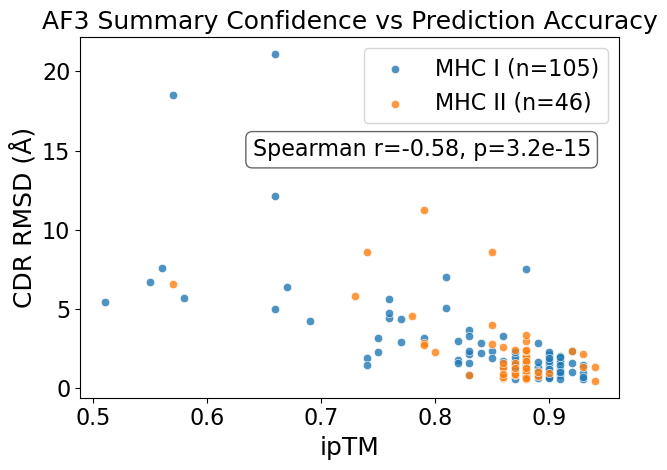

In [4]:
y = pdb_af3.select("cdr_rmsd_af3_4").to_series().to_numpy()
x = pdb_af3.select("iptm").to_series().to_numpy()
mhc_class = pdb_af3.select("mhc_class").to_series().to_numpy()

fig = plot_correlation(
    x,
    y,
    mhc_class,
    ylabel="CDR RMSD (Å)",
    xlabel="ipTM",
    method="spearman",
    title="AF3 Summary Confidence vs Prediction Accuracy",
)

## CDR RMSD vs mahalanobis distance


### Class I


In [5]:
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)

cl = ["I", "II"]
dists = []
rmsds = []
mhc_classes = []
consensi = []

for c in cl:
    focal_class = pdb_af3.filter(pl.col("mhc_class") == c)
    focal_dgeom_ndarr = dgeom_ndarr_from_dgeom_series(
        focal_class.select("true_dgeom").to_series()
    )

    template_dgeom_ndarr = dgeom_ndarr_from_dgeom_series(
        template_dgeom.filter(pl.col("mhc_class") == c).select("dgeom").to_series()
    )

    mu, invcov = mn_distr_from_dgeom_ndarr(template_dgeom_ndarr)

    dist, prob = mn_distance_from(focal_dgeom_ndarr, mu, invcov)

    y = focal_class.select("docking_rmsd_af3_4").to_series().to_numpy()
    mhc_class = focal_class.select("mhc_class").to_series().to_numpy()

    dists.append(dist)
    rmsds.append(y)
    mhc_classes.append(mhc_class)
    consensi.append(mu)

dists = np.concat(dists)
rmsds = np.concat(rmsds)
mhc_classes = np.concat(mhc_classes)

### Consensus geometry


<Axes3D: xlabel='MHC x', ylabel='MHC y', zlabel='MHC z'>

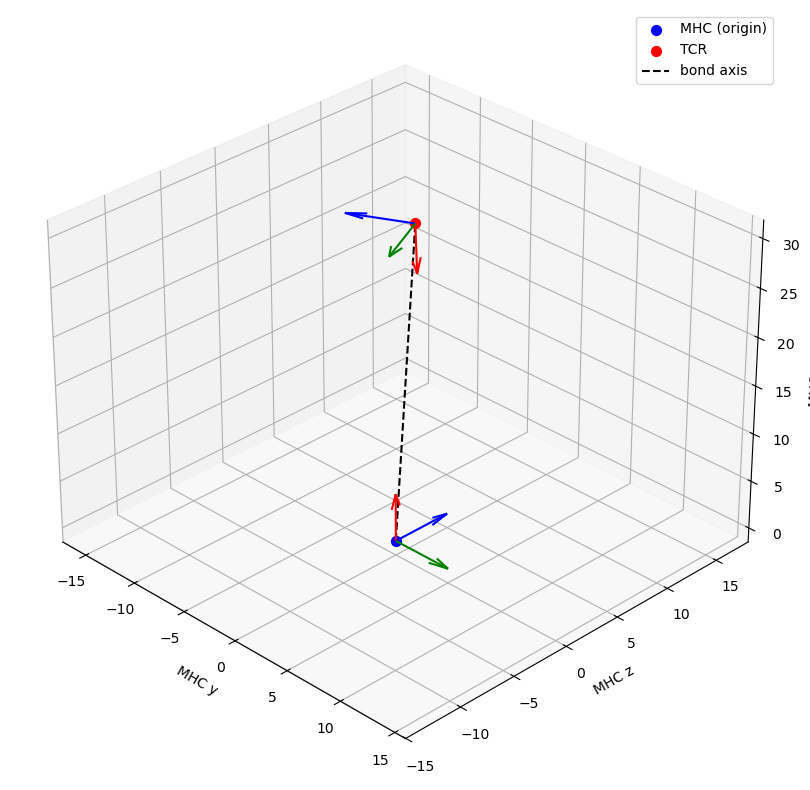

In [6]:
from tcrtrifold.viz_utils import plot_docking_geometry

# cls 1
plot_docking_geometry(*un_cossin_embed(consensi[0][np.newaxis, :])[0])

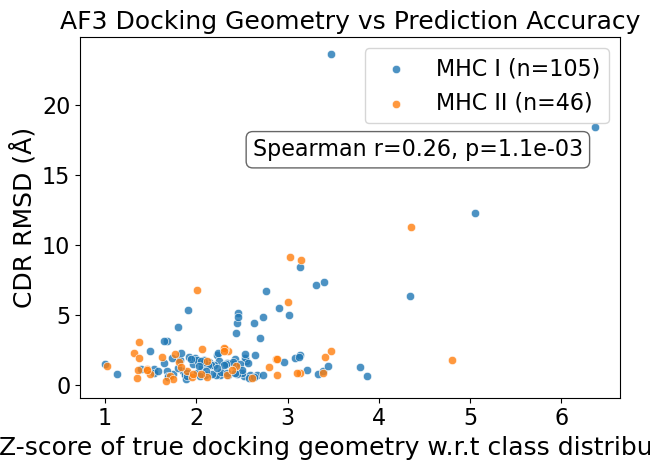

In [7]:
fig = plot_correlation(
    dists,
    rmsds,
    mhc_classes,
    xlabel="Z-score of true docking geometry w.r.t class distribution",
    ylabel="CDR RMSD (Å)",
    method="spearman",
    title="AF3 Docking Geometry vs Prediction Accuracy",
)

## Pred docking geom


In [8]:
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)

cl = ["I", "II"]
dists = []
rmsds = []
mhc_classes = []
consensi = []

for c in cl:
    focal_class = pdb_af3.filter(pl.col("mhc_class") == c)
    focal_dgeom_ndarr = dgeom_ndarr_from_dgeom_series(
        focal_class.select("pred_dgeom_4").to_series()
    )

    template_dgeom_ndarr = dgeom_ndarr_from_dgeom_series(
        template_dgeom.filter(pl.col("mhc_class") == c).select("dgeom").to_series()
    )

    mu, invcov = mn_distr_from_dgeom_ndarr(template_dgeom_ndarr)

    dist, prob = mn_distance_from(focal_dgeom_ndarr, mu, invcov)

    y = focal_class.select("docking_rmsd_af3_4").to_series().to_numpy()
    mhc_class = focal_class.select("mhc_class").to_series().to_numpy()

    dists.append(dist)
    rmsds.append(y)
    mhc_classes.append(mhc_class)
    consensi.append(mu)

dists = np.concat(dists)
rmsds = np.concat(rmsds)
mhc_classes = np.concat(mhc_classes)

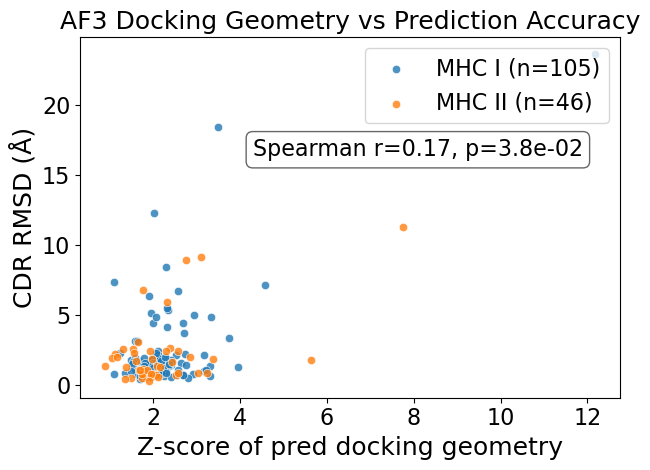

In [9]:
fig = plot_correlation(
    dists,
    rmsds,
    mhc_classes,
    xlabel="Z-score of pred docking geometry",
    ylabel="CDR RMSD (Å)",
    method="spearman",
    title="AF3 Docking Geometry vs Prediction Accuracy",
)

## Peptide length


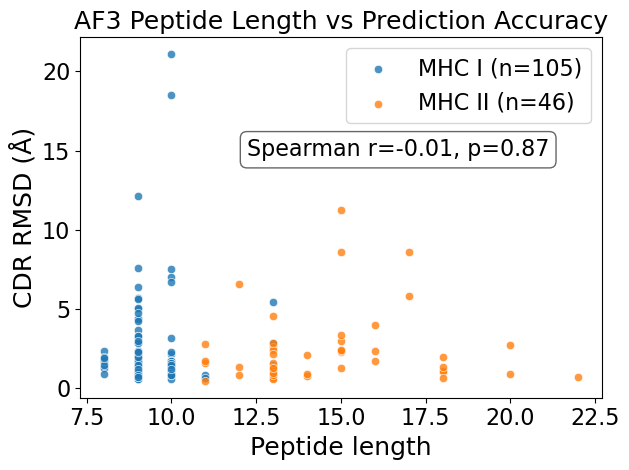

In [10]:
y = pdb_af3.select("cdr_rmsd_af3_4").to_series().to_numpy()
x = pdb_af3.select(pl.col("peptide").str.len_chars()).to_series().to_numpy()
mhc_class = pdb_af3.select("mhc_class").to_series().to_numpy()

fig = plot_correlation(
    x,
    y,
    mhc_class,
    ylabel="CDR RMSD (Å)",
    xlabel="Peptide length",
    method="spearman",
    title="AF3 Peptide Length vs Prediction Accuracy",
)

In [11]:
# y = pdb_af3.select("cdr_rmsd_af3_4").to_series().to_numpy()
# x = pdb_af3.select(pl.col("tcr_2_cdr_3").str.len_chars()).to_series().to_numpy()
# mhc_class = pdb_af3.select("mhc_class").to_series().to_numpy()


# fig = plot_correlation(
#     x,
#     y,
#     mhc_class,
#     xlabel="Z-score of true docking geometry w.r.t class consensus distribution",
#     ylabel="CDR RMSD (Å)",
#     method="spearman",
#     title="AlphaFold3 CDR RMSD vs Z-score of docking geometry",
# )

In [12]:
# y = pdb_af3.select("cdr_rmsd_af3_4").to_series().to_numpy()
# x = (
#     pdb_af3.with_columns(
#         pl.when(pl.col("mhc_class") == "I")
#         .then(pl.lit(1))
#         .otherwise(pl.lit(2))
#         .alias("mhc_class_numeric")
#     )
#     .select(pl.col("mhc_class_numeric"))
#     .to_series()
#     .to_numpy()
# )
# mhc_class = pdb_af3.select("mhc_class").to_series().to_numpy()


# fig = plot_correlation(
#     x,
#     y,
#     mhc_class,
#     xlabel="Z-score of true docking geometry w.r.t class consensus distribution",
#     ylabel="CDR RMSD (Å)",
#     method="spearman",
#     title="AlphaFold3 CDR RMSD vs Z-score of docking geometry",
# )

In [13]:
pdb_af3.filter(pl.col("mhc_class") == "I", pl.col("replication")).select(
    "cdr_rmsd_af3_4"
).min()

cdr_rmsd_af3_4
f64
0.601591
